# **Step #1: Explore and prep data**

In [13]:
import os
import pandas as pd 

df = pd.read_csv('bank+marketing/bank-additional/bank-additional/bank-additional-full.csv', delimiter=';')
df

,age,job,marital,education,default,housing,loan,contact,month,day_of_week,...,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y
0,56,housemaid,married,basic.4y,no,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
1,57,services,married,high.school,unknown,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
2,37,services,married,high.school,no,yes,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
3,40,admin.,married,basic.6y,no,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
4,56,services,married,high.school,no,no,yes,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
41183,73,retired,married,professional.course,no,yes,no,cellular,nov,fri,...,1,999,0,nonexistent,-1.1,94.767,-50.8,1.028,4963.6,yes
41184,46,blue-collar,married,professional.course,no,no,no,cellular,nov,fri,...,1,999,0,nonexistent,-1.1,94.767,-50.8,1.028,4963.6,no
41185,56,retired,married,university.degree,no,yes,no,cellular,nov,fri,...,2,999,0,nonexistent,-1.1,94.767,-50.8,1.028,4963.6,no
41186,44,technician,married,professional.course,no,no,no,cellular,nov,fri,...,1,999,0,nonexistent,-1.1,94.767,-50.8,1.028,4963.6,yes


In [14]:
# list and drop columns that are less related to the target  based on my judgment
cols_to_drop = ['duration', 'emp.var.rate', 'cons.price.idx', 'cons.conf.idx', 'euribor3m', 'nr.employed']
# at the same time, rename the columns so they are undesratndable.
df = df.drop(columns=cols_to_drop).rename(columns={ 'job': 'job_type',
                                                    'default': 'default_status', 
                                                    'housing': 'housing_loan_status',
                                                    'loan': 'personal_loan_status', 
                                                    'contact': 'contact_type',
                                                    'month': 'contact_month', 
                                                    'day_of_week': 'contact_day_of_week',
                                                    'compaign': 'num_contacts',
                                                    'pdays': 'days_last_contact',
                                                    'previous': 'previous_contacts', 
                                                    'poutcome':'previous_outcome', 
                                                    'y': 'result'
    
})\
# convert the target to numerical values 
df['result'] = df['result'].replace({'yes': 1, 'no': 0}).astype(int)

In [15]:
df.head()

,age,job_type,marital,education,default_status,housing_loan_status,personal_loan_status,contact_type,contact_month,contact_day_of_week,campaign,days_last_contact,previous_contacts,previous_outcome,result
0,56,housemaid,married,basic.4y,no,no,no,telephone,may,mon,1,999,0,nonexistent,0
1,57,services,married,high.school,unknown,no,no,telephone,may,mon,1,999,0,nonexistent,0
2,37,services,married,high.school,no,yes,no,telephone,may,mon,1,999,0,nonexistent,0
3,40,admin.,married,basic.6y,no,no,no,telephone,may,mon,1,999,0,nonexistent,0
4,56,services,married,high.school,no,no,yes,telephone,may,mon,1,999,0,nonexistent,0


In [16]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 41188 entries, 0 to 41187
Data columns (total 15 columns):
 #   Column                Non-Null Count  Dtype
---  ------                --------------  -----
 0   age                   41188 non-null  int64
 1   job_type              41188 non-null  str  
 2   marital               41188 non-null  str  
 3   education             41188 non-null  str  
 4   default_status        41188 non-null  str  
 5   housing_loan_status   41188 non-null  str  
 6   personal_loan_status  41188 non-null  str  
 7   contact_type          41188 non-null  str  
 8   contact_month         41188 non-null  str  
 9   contact_day_of_week   41188 non-null  str  
 10  campaign              41188 non-null  int64
 11  days_last_contact     41188 non-null  int64
 12  previous_contacts     41188 non-null  int64
 13  previous_outcome      41188 non-null  str  
 14  result                41188 non-null  int64
dtypes: int64(5), str(10)
memory usage: 4.7 MB


In [17]:
df['result'].value_counts()

result
0    36548
1     4640
Name: count, dtype: int64

In [18]:
from sklearn.model_selection import train_test_split

X = df.drop(columns='result')
y = df['result']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=0
)

# **Step 2: Build a pipeline of training**

In [19]:
from sklearn.pipeline import Pipeline
from category_encoders.target_encoder import TargetEncoder
from xgboost import XGBClassifier

In [20]:
estimators = [
    ('encoder', TargetEncoder()), 
    ('clf', XGBClassifier(random_state=0)) # can customize objective function with the objective parameter
]
pipe = Pipeline(steps=estimators)
pipe

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('encoder', ...), ('clf', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,verbose,0
,cols,None
,drop_invariant,False
,return_df,True
,handle_missing,'value'
,handle_unknown,'value'
,min_samples_leaf,20


# **Step #3: Set up hyperparameter tuning**

In [35]:
from skopt import BayesSearchCV
from skopt.space import Real, Categorical, Integer

search_space = {
    'clf__max_depth': Integer (2, 8), 
    'clf__learning_rate': Real(0.0001, 1, prior='log-uniform'), 
    'clf__subsample': Real(0.5, 1.0), 
    'clf__colsample_bytree': Real(0.5, 1.0), 
    'clf__colsample_bylevel': Real(0.5, 1.0),  
    'clf__colsample_bynode': Real(0.5, 1.0), 
    'clf__reg_alpha': Real(0.0, 10.0),  
    'clf__reg_lambda': Real(0.0, 10.0), 
    'clf__gamma': Real(0.0, 10.0)
}
opt = BayesSearchCV(pipe, search_space, cv=5, n_iter=20, scoring='roc_auc', random_state=8)
# In reality, u may consider setting cv n n_iter to higher values

# **Step #4: Training the XGBoost model**

In [36]:
opt.fit(X_train, y_train)

,estimator,"Pipeline(step...=None, ...))])"
,search_spaces,"{'clf__colsample_bylevel': Real(low=0.5,...m='normalize'), 'clf__colsample_bynode': Real(low=0.5,...m='normalize'), 'clf__colsample_bytree': Real(low=0.5,...m='normalize'), 'clf__gamma': Real(low=0.0,...m='normalize'), ...}"
,optimizer_kwargs,None
,n_iter,20
,scoring,'roc_auc'
,fit_params,None
,n_jobs,1
,n_points,1
,iid,'deprecated'
,refit,True
,cv,5


# **Step #5: Evaluate the model and make predictions**


In [37]:
opt.best_estimator_

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('encoder', ...), ('clf', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,verbose,0
,cols,"['job_type', 'marital', ...]"
,drop_invariant,False
,return_df,True
,handle_missing,'value'
,handle_unknown,'value'
,min_samples_leaf,20


In [38]:
opt.best_score_

np.float64(0.7709695486700272)

In [39]:
opt.score(X_test, y_test)

0.7734100812538328

In [40]:
opt.predict(X_test)

array([0, 0, 0, ..., 0, 0, 1], shape=(8238,))

In [41]:
opt.predict_proba(X_test)

array([[0.9477797 , 0.0522203 ],
       [0.96217686, 0.03782314],
       [0.93457395, 0.06542606],
       ...,
       [0.8636436 , 0.13635643],
       [0.96371096, 0.03628905],
       [0.3115641 , 0.6884359 ]], shape=(8238, 2), dtype=float32)

# **Step #6: Measure feature impoartance (optional)**

In [42]:
opt.best_estimator_.steps

[('encoder',
  TargetEncoder(cols=['job_type', 'marital', 'education', 'default_status',
                      'housing_loan_status', 'personal_loan_status',
                      'contact_type', 'contact_month', 'contact_day_of_week',
                      'previous_outcome'])),
 ('clf',
  XGBClassifier(base_score=None, booster=None, callbacks=None,
                colsample_bylevel=0.9425384185492701,
                colsample_bynode=0.9095956806239844,
                colsample_bytree=0.706128679361455, device=None,
                early_stopping_rounds=None, enable_categorical=False,
                eval_metric=None, feature_types=None, feature_weights=None,
                gamma=1.6598135411398998, grow_policy=None, importance_type=None,
                interaction_constraints=None, learning_rate=0.7339813800218159,
                max_bin=None, max_cat_threshold=None, max_cat_to_onehot=None,
                max_delta_step=None, max_depth=7, max_leaves=None,
                min_ch

<Axes: title={'center': 'Feature importance'}, xlabel='Importance score', ylabel='Features'>

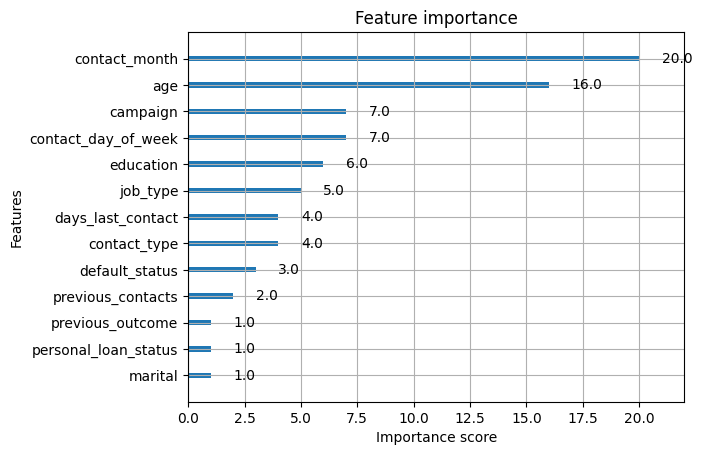

In [43]:
from xgboost import plot_importance

xgboost_step = opt.best_estimator_.steps[1]
xgboost_model = xgboost_step[1]
plot_importance(xgboost_model)